In [1]:
import sklearn
from pathlib import Path
import matplotlib.pyplot as plt

IMAGES_PATH = Path() / "output" / "15_Sequences_RNNs_a_CNNs"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    print("Saving figure", fig_id)

In [2]:
# to make this notebook's output stable across runs
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silent warning for TF 0 = all logs, 1 = INFO, 2 = WARNING, 3 = ERROR 

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
print("sklearn version:", sklearn.__version__)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

TensorFlow version: 2.20.0
sklearn version: 1.7.2


In [3]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


In [4]:
# Forecasting a Time Series: build a model to forecast the number of passengers riding bus or rail in Chicago
filepath = tf.keras.utils.get_file("ridership.tgz", "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".", extract=True)
if "_extracted" in filepath:
    ridership_path = Path(filepath) / "ridership"
else:
    ridership_path = Path(filepath).with_name("ridership")

In [5]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership_extracted/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates = ["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis = 1)
df = df.drop_duplicates()

In [6]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Saving figure daily_ridership_plot_fig15-6


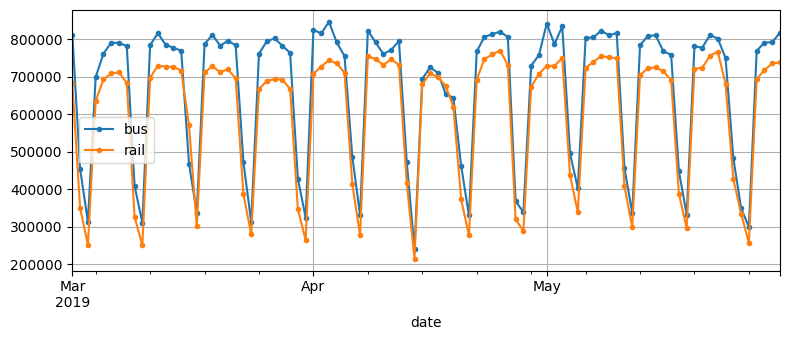

In [7]:
import matplotlib.pyplot as plt
df["2019-03":"2019-05"].plot(grid = True, marker = ".", figsize = (8, 3.5))
save_fig("daily_ridership_plot_fig15-6")  # extra code – saves the figure for the book
plt.show()

Saving figure differencing_plot_fig15-7


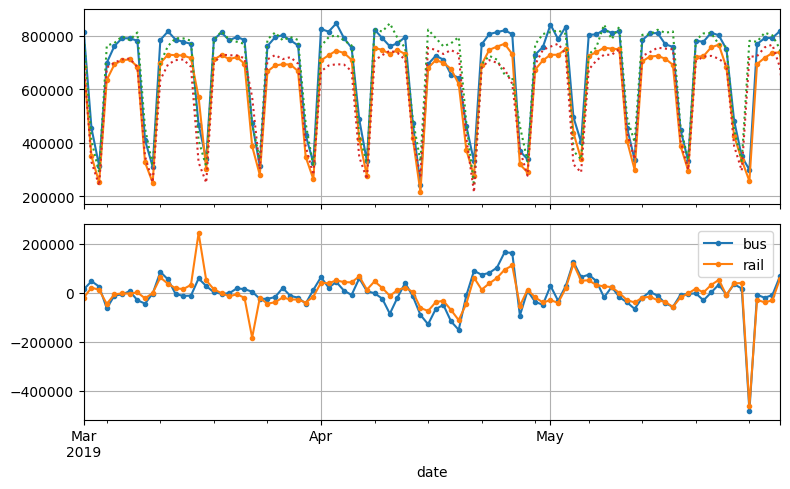

In [8]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot
save_fig("differencing_plot_fig15-7")  # extra code – saves the figure for the book
plt.show()

In [9]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [10]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [11]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Saving figure long_term_ridership_plot_fig15-8


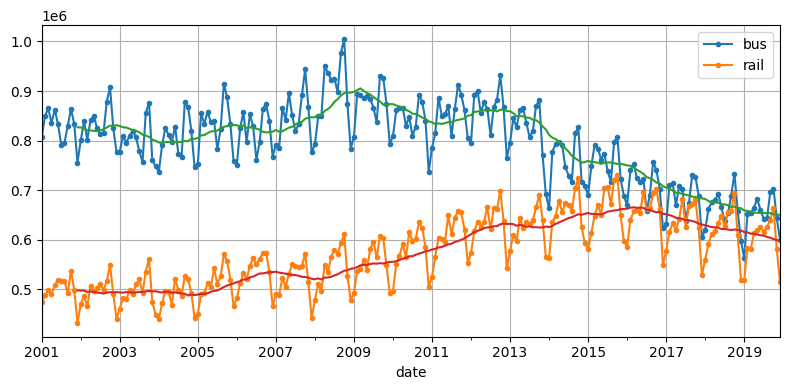

In [12]:
period = slice("2001", "2019")
try:
    df_monthly = df.select_dtypes(include="number").resample('ME').mean()  # compute the mean for each month
    rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
except ValueError as ex:
    try:
        df_monthly = df.select_dtypes(include="number").resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
    except ValueError as ex:
        df_monthly = df.resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
save_fig("long_term_ridership_plot_fig15-8")  # extra code – saves the figure for the book
plt.show()

Saving figure monthly_difference_plot_fig15-9


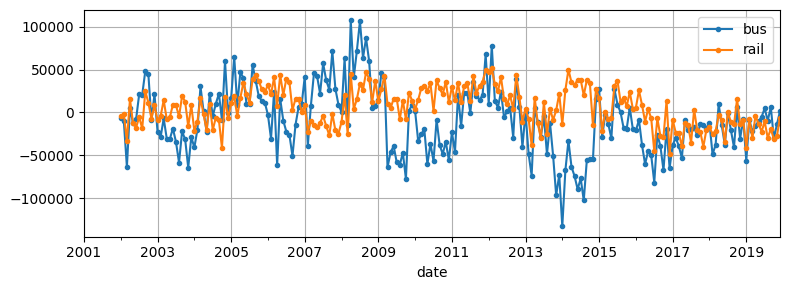

In [13]:
df_monthly.diff(12)[period].plot(grid = True, marker = ".", figsize = (8, 3))
save_fig("monthly_difference_plot_fig15-9")  # extra code – saves the figure 15-9
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019--05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series, order = (1, 0, 0), seasonal_order = (0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast().iloc   #  Accessing Pandas Series by index directly is deprecated, use `ser.iloc[pos] insted

In [15]:
y_pred[0]  # ARIMA forecast

427758.62641035335

In [16]:
df["rail"].loc["2019-06-01"]  # target value

379044

In [17]:
df["rail"].loc["2019-05-25"]  # naive forecast (value from one week earlier)

426932

In [18]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], order = (1, 0, 0), seasonal_order = (0, 1, 1, 7))
    model = model.fit()
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index = time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()

In [19]:
mae

32040.720089453378

/tmp/ipykernel_586/2292568549.py:4: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")


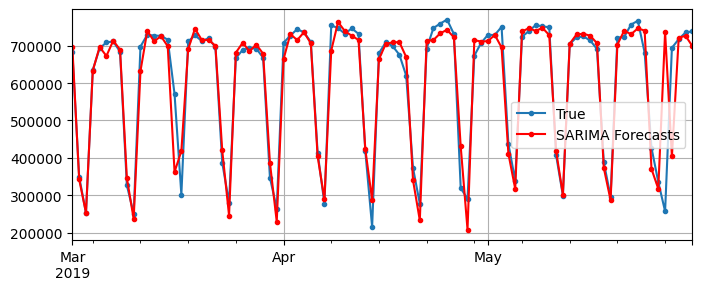

In [20]:
# extra code – displays the SARIMA forecasts
fig, ax = plt.subplots(figsize=(8, 3))
rail_series.loc[time_period].plot(label="True", ax=ax, marker=".", grid=True)
ax.plot(y_preds, color="r", marker=".", label="SARIMA Forecasts")
plt.legend()
plt.show()

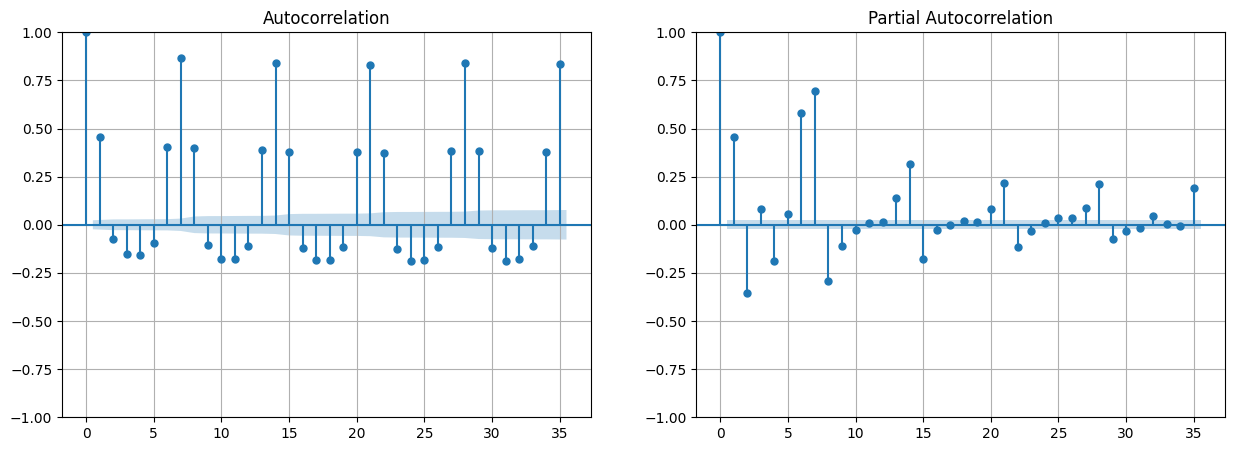

In [21]:
# extra code – shows how to plot the Autocorrelation Function (ACF) and the
#              Partial Autocorrelation Function (PACF)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()
plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

In [22]:
import tensorflow as tf

my_series = [0, 1, 2, 3, 4, 5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    my_series,
    targets=my_series[3:],  # the targets are 3 steps into the future
    sequence_length=3,
    batch_size=2
)
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [23]:
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [24]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift=1):
    for element in window_dataset:
        print(f"{element}", end=" ")
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


In [25]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
    print(f"{window_tensor}")

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [26]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

In [27]:
dataset = to_windows(tf.data.Dataset.range(6), 4)
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>)]

In [28]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

In [29]:
seq_length = 56
tf.random.set_seed(42)  # extra code – ensures reproducibility
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

In [30]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [seq_length]),
    tf.keras.layers.Dense(1)
])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae", patience=50, restore_best_weights=True)
opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
history = model.fit(train_ds, validation_data=valid_ds, epochs=500, callbacks=[early_stopping_cb])

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0705 - mae: 0.2903 - val_loss: 0.0136 - val_mae: 0.1384
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0112 - mae: 0.1144 - val_loss: 0.0064 - val_mae: 0.0851
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081 - mae: 0.0949 - val_loss: 0.0058 - val_mae: 0.0818
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - mae: 0.0841 - val_loss: 0.0055 - val_mae: 0.0754
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060 - mae: 0.0794 - val_loss: 0.0047 - val_mae: 0.0688
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - mae: 0.0796 - val_loss: 0.0047 - val_mae: 0.0681
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - mae: 0.0741 - val_loss: 0.0041 - val_mae: 0.0647
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050 - mae: 0.0717 - val_loss: 0.0042 - val_mae: 0.0641
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.005

In [31]:
# extra code – evaluates the model
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - mae: 0.0370


37040.31929373741

In [32]:
# Forecasting Using a Simple RNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 1]),
    tf.keras.layers.SimpleRNN(1)])

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0358 - mae: 0.1856 - val_loss: 0.0190 - val_mae: 0.1327
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0183 - mae: 0.1671 - val_loss: 0.0180 - val_mae: 0.1353
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 - mae: 0.1623 - val_loss: 0.0172 - val_mae: 0.1371
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171 - mae: 0.1595 - val_loss: 0.0166 - val_mae: 0.1386
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0167 - mae: 0.1598 - val_loss: 0.0164 - val_mae: 0.1362
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0163 - mae: 0.1586 - val_loss: 0.0160 - val_mae: 0.1360
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0159 - mae: 0.1581 - val_loss: 0.0158 - val_mae: 0.1349
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0156 - mae: 0.1561 - val_loss: 0.0150 - val_mae: 0.1419
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.01

128780.23087978363

In [35]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
univar_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 1]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)  # no activation function by default
])

In [36]:
univar_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate = 0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0229 - mae: 0.1503 - val_loss: 0.0030 - val_mae: 0.0596
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - mae: 0.0605 - val_loss: 0.0023 - val_mae: 0.0415
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - mae: 0.0551 - val_loss: 0.0020 - val_mae: 0.0346
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - mae: 0.0537 - val_loss: 0.0020 - val_mae: 0.0374
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - mae: 0.0528 - val_loss: 0.0019 - val_mae: 0.0361
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - mae: 0.0464 - val_loss: 0.0025 - val_mae: 0.0513
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - mae: 0.0506 - val_loss: 0.0019 - val_mae: 0.0366
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - mae: 0.0461 - val_loss: 0.0023 - val_mae: 0.0420
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

28628.339990973473

In [38]:
# Forecasting Using a Deep RNN
deep_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences = True),
    tf.keras.layers.SimpleRNN(32, return_sequences = True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)])

deep_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 32)       │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate = 0.01)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0214 - mae: 0.1479 - val_loss: 0.0060 - val_mae: 0.0900
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0053 - mae: 0.0692 - val_loss: 0.0021 - val_mae: 0.0382
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0045 - mae: 0.0617 - val_loss: 0.0021 - val_mae: 0.0382
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - mae: 0.0581 - val_loss: 0.0022 - val_mae: 0.0397
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0038 - mae: 0.0552 - val_loss: 0.0021 - val_mae: 0.0382
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039 - mae: 0.0575 - val_loss: 0.0024 - val_mae: 0.0466
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0037 - mae: 0.0571 - val_loss: 0.0027 - val_mae: 0.0491
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0034 - mae: 0.0540 - val_loss: 0.0023 - val_mae: 0.0414
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

31569.525599479675

In [40]:
# Forecasting Multivariate Time Series
df_mulvar = df[["bus", "rail"]] / 1e6  # use both bus & rail series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)  # one-hot encode the day type

mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

tf.random.set_seed(42)  # extra code – ensures reproducibility
train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)  # extra code – ensures reproducibility
mulvar_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds, learning_rate=0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0175 - mae: 0.1317 - val_loss: 0.0016 - val_mae: 0.0441
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - mae: 0.0544 - val_loss: 0.0022 - val_mae: 0.0578
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024 - mae: 0.0500 - val_loss: 0.0012 - val_mae: 0.0391
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0415 - val_loss: 0.0013 - val_mae: 0.0422
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - mae: 0.0401 - val_loss: 0.0010 - val_mae: 0.0360
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0434 - val_loss: 8.2281e-04 - val_mae: 0.0304
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0438 - val_loss: 6.8350e-04 - val_mae: 0.0261
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - mae: 0.0422 - val_loss: 8.0133e-04 - val_mae: 0.0305
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

23217.011243104935

In [41]:
# extra code – build and train a multitask RNN that forecasts both bus and rail

tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds, learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0318 - mae: 0.1770 - val_loss: 0.0034 - val_mae: 0.0683
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - mae: 0.0633 - val_loss: 0.0021 - val_mae: 0.0510
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - mae: 0.0517 - val_loss: 0.0026 - val_mae: 0.0604
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - mae: 0.0486 - val_loss: 0.0016 - val_mae: 0.0439
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - mae: 0.0459 - val_loss: 0.0015 - val_mae: 0.0427
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mae: 0.0445 - val_loss: 9.9353e-04 - val_mae: 0.0330
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - mae: 0.0432 - val_loss: 0.0010 - val_mae: 0.0335
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0429 - val_loss: 0.0011 - val_mae: 0.0365
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 

24771.055206656456

In [42]:
# extra code – evaluates the naive forecasts for bus
bus_naive = mulvar_valid["bus"].shift(7)[seq_length:]
bus_target = mulvar_valid["bus"][seq_length:]
(bus_target - bus_naive).abs().mean() * 1e6

43441.63157894738

In [43]:
# extra code – evaluates the multitask RNN's forecasts both bus and rail
Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(["bus", "rail"]):
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
bus 25857
rail 23684


In [44]:
# Forecasting Several Time Steps Ahead
import numpy as np

X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


Saving figure forecast_ahead_plot_fig15-11


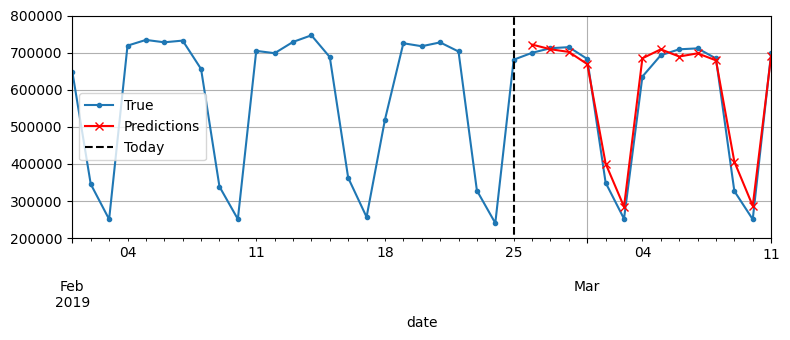

In [45]:
# extra code – generates and saves Figure 15–11

# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred = pd.Series(X[0, -14:, 0], index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot(label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
save_fig("forecast_ahead_plot_fig15-11")
plt.show()

In [46]:
tf.random.set_seed(42)  # extra code – ensures reproducibility

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(), targets=None, sequence_length=seq_length + 14, batch_size=32, shuffle=True, seed=42
).map(split_inputs_and_targets)
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(), targets=None, sequence_length=seq_length + 14, batch_size=32
).map(split_inputs_and_targets)

tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(14)
])

# extra code – compiles, fits, and evaluates the model, like earlier
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds, learning_rate = 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0948 - mae: 0.3243 - val_loss: 0.0262 - val_mae: 0.1775
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0190 - mae: 0.1597 - val_loss: 0.0153 - val_mae: 0.1363
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - mae: 0.1381 - val_loss: 0.0118 - val_mae: 0.1242
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - mae: 0.1270 - val_loss: 0.0101 - val_mae: 0.1136
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107 - mae: 0.1178 - val_loss: 0.0090 - val_mae: 0.1070
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0097 - mae: 0.1111 - val_loss: 0.0079 - val_mae: 0.0993
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0089 - mae: 0.1046 - val_loss: 0.0071 - val_mae: 0.0950
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0083 - mae: 0.1007 - val_loss: 0.0065 - val_mae: 0.0905
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.00

33963.434398174286

In [47]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]  # shape [1, 56, 5]
Y_pred = ahead_model.predict(X)  # shape [1, 14]

my_series = tf.data.Dataset.range(7)
dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])>]

In [48]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]])>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]])>)]

In [49]:
def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                       batch_size=32, shuffle=False, seed=None):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)    #     return ds.batch(batch_size).repeat() cause the infinite dataset problem

seq2seq_train = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(mulvar_valid)

In [50]:
mulvar_train.shape


(1096, 5)

In [51]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.Dense(14)
    # equivalent: tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(14))
    # also equivalent: tf.keras.layers.Conv1D(14, kernel_size=1)
])

fit_and_evaluate(seq2seq_model, seq2seq_train, seq2seq_valid, learning_rate = 0.1)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0393 - mae: 0.2083 - val_loss: 0.0132 - val_mae: 0.1174


/home/fliu2/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0098 - mae: 0.1000 - val_loss: 0.0080 - val_mae: 0.0866
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0073 - mae: 0.0826 - val_loss: 0.0064 - val_mae: 0.0749
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - mae: 0.0762 - val_loss: 0.0060 - val_mae: 0.0733
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0058 - mae: 0.0714 - val_loss: 0.0055 - val_mae: 0.0694
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0053 - mae: 0.0680 - val_loss: 0.0049 - val_mae: 0.0630
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - mae: 0.0663 - val_loss: 0.0052 - val_mae: 0.0683
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049 - mae: 0.0645 - val_loss: 0.0047 - val_mae: 0.0623
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - mae: 0.0631 - val_loss: 0.0044 - val_mae: 0.0589
Epoch 10/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - l

46351.67866945267

In [52]:
X = mulvar_valid.to_numpy()[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]  # only the last time step's output

Y_pred_valid = seq2seq_model.predict(seq2seq_valid)
for ahead in range(14):
    preds = pd.Series(Y_pred_valid[:-1, -1, ahead],
                      index=mulvar_valid.index[56 + ahead : -14 + ahead])
    mae = (preds - mulvar_valid["rail"]).abs().mean() * 1e6
    print(f"MAE for +{ahead + 1}: {mae:,.0f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
      1/Unknown 0s 110ms/stepWARNING:tensorflow:5 out of the last 18 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fa4a45194e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
MAE for +1: 24,299
MAE for +2: 28,940
MAE for +3: 28,265
MAE for +4: 32,477
MAE for +5: 32,592
MAE for +6: 34,036
MAE for +7: 33,663
MAE for +8: 34,601
MAE for +9: 34,751


In [53]:
# Deep RNNs with Layer Norm
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units, activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))

        norm_outputs_prev = states[0]
        norm_outputs = (tf.matmul(inputs, self.kernel) + tf.matmul(norm_outputs_prev, self.recurrent_kernel) + self.bias)

        # Layer norm
        mean, var = tf.nn.moments(norm_outputs, axes=[-1], keepdims=True)
        norm_outputs = (norm_outputs - mean) / tf.sqrt(var + 1e-5)
        norm_outputs = self.gamma * norm_outputs + self.beta

        norm_outputs = tf.nn.tanh(norm_outputs)
        return norm_outputs, [norm_outputs]

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Main weights
        self.kernel = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            name="kernel"
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units),
            initializer="orthogonal",
            name="recurrent_kernel"
        )
        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            name="bias"
        )

        # Optional: layer norm weights
        self.gamma = self.add_weight(
            shape=(self.units,),
            initializer="ones",
            name="gamma"
        )
        self.beta = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            name="beta"
        )

        self.built = True

In [54]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
custom_ln_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True),
    tf.keras.layers.Dense(14)
])                                                       

In [55]:
custom_ln_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (RNN)                       │ (None, None, 32)       │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, None, 14)       │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742 (6.80 KB)

 Trainable params: 1,742 (6.80 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
fit_and_evaluate(custom_ln_model, seq2seq_train, seq2seq_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0701 - mae: 0.2646 - val_loss: 0.0156 - val_mae: 0.1341
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0125 - mae: 0.1269 - val_loss: 0.0120 - val_mae: 0.1107
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0096 - mae: 0.1070 - val_loss: 0.0101 - val_mae: 0.1015
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0082 - mae: 0.0963 - val_loss: 0.0085 - val_mae: 0.0923
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - mae: 0.0902 - val_loss: 0.0083 - val_mae: 0.0904
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0083 - mae: 0.0904


90391.05474948883

In [57]:
# Extra Material – Creating a Custom RNN Class
class MyRNN(tf.keras.layers.Layer):
    def __init__(self, cell, return_sequences=False, **kwargs):
        super().__init__(**kwargs)
        self.cell = cell
        self.return_sequences = return_sequences

    def get_initial_state(self, inputs):
        try:
            return self.cell.get_initial_state(inputs)
        except AttributeError:
            # fallback to zeros if self.cell has no get_initial_state() method
            batch_size = tf.shape(inputs)[0]
            return [tf.zeros([batch_size, self.cell.state_size],
                             dtype=inputs.dtype)]

    @tf.function
    def call(self, inputs):
        states = self.get_initial_state(inputs)
        shape = tf.shape(inputs)
        batch_size = shape[0]
        n_steps = shape[1]
        sequences = tf.TensorArray(
            inputs.dtype, size=(n_steps if self.return_sequences else 0))
        outputs = tf.zeros(shape=[batch_size, self.cell.output_size],
                           dtype=inputs.dtype)
        for step in tf.range(n_steps):
            outputs, states = self.cell(inputs[:, step], states)
            if self.return_sequences:
                sequences = sequences.write(step, outputs)

        if self.return_sequences:
            # stack the outputs into an array of shape
            # [time steps, batch size, dims], then transpose it to shape
            # [batch size, time steps, dims]
            return tf.transpose(sequences.stack(), [1, 0, 2])
        else:
            return outputs

In [58]:
tf.random.set_seed(42)

custom_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    MyRNN(LNSimpleRNNCell(32), return_sequences=True),
    tf.keras.layers.Dense(14)
])

fit_and_evaluate(custom_model, seq2seq_train, seq2seq_valid, learning_rate=0.1, epochs=5)

Epoch 1/5


/home/fliu2/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential_9/my_rnn/ln_simple_rnn_cell_1/kernel', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/recurrent_kernel', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/bias', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/gamma', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/beta', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/simple_rnn_cell_1/kernel', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/simple_rnn_cell_1/recurrent_kernel', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/simple_rnn_cell_1/bias', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/layer_normalization_1/gamma', 'sequential_9/my_rnn/ln_simple_rnn_cell_1/layer_normalization_1/beta'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1730 - mae: 0.4475 - val_loss: 0.0390 - val_mae: 0.2085
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0323 - mae: 0.1848 - val_loss: 0.0218 - val_mae: 0.1449
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0206 - mae: 0.1451 - val_loss: 0.0163 - val_mae: 0.1264
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0158 - mae: 0.1275 - val_loss: 0.0131 - val_mae: 0.1139
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0128 - mae: 0.1150 - val_loss: 0.0109 - val_mae: 0.1035
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0109 - mae: 0.1035


103459.96171236038

In [59]:
# LSTM (long short-term memory)
tf.random.set_seed(42)  # extra code – ensures reproducibility

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.LSTM(32, return_sequences = True),
    tf.keras.layers.Dense(14)])

fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid, learning_rate = 0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0554 - mae: 0.2573 - val_loss: 0.0192 - val_mae: 0.1677
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0175 - mae: 0.1601 - val_loss: 0.0178 - val_mae: 0.1471
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0159 - mae: 0.1522 - val_loss: 0.0168 - val_mae: 0.1421
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0151 - mae: 0.1475 - val_loss: 0.0160 - val_mae: 0.1378
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0143 - mae: 0.1428 - val_loss: 0.0153 - val_mae: 0.1343
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0153 - mae: 0.1343


134310.0368976593

In [60]:
# GRUs
tf.random.set_seed(42)  # extra code – ensures reproducibility
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)])

fit_and_evaluate(gru_model, seq2seq_train, seq2seq_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0595 - mae: 0.2687 - val_loss: 0.0190 - val_mae: 0.1592
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0154 - mae: 0.1439 - val_loss: 0.0150 - val_mae: 0.1323
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0125 - mae: 0.1292 - val_loss: 0.0132 - val_mae: 0.1231
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0114 - mae: 0.1223 - val_loss: 0.0122 - val_mae: 0.1179
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0106 - mae: 0.1171 - val_loss: 0.0114 - val_mae: 0.1140
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114 - mae: 0.1140


114018.54455471039

Using One-Dimensional Convolutional Layers to Process Sequences
  |-----0-----|      |-----3----|      |--... |-------52------|
         |-----1----|      |-----4----|   ... |       |-------53------|
               |-----2----|     |------5--...-51------|       |-------54------|
X:  0  1  2  3  4  5  6  7  8  9 10 11 12 ...  104 105 106 107 108 109 110 111
Y:      from 4     6     8    10    12    ...      106     108     110     112
         to 17    19    21    23    25    ...      119     121     123     125

In [61]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
conv_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = [None, 5]),
    tf.keras.layers.Conv1D(filters = 32, kernel_size = 4, strides = 2, activation = "relu"),
    tf.keras.layers.GRU(32, return_sequences = True),
    tf.keras.layers.Dense(14)
])

longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112, shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)
downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

conv_rnn_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, None, 32)       │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 32)       │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, None, 14)       │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,470 (29.18 KB)

 Trainable params: 7,470 (29.18 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
fit_and_evaluate(conv_rnn_model, downsampled_train, downsampled_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
     31/Unknown 2s 18ms/step - loss: 0.1095 - mae: 0.3829

/home/fliu2/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0574 - mae: 0.2632 - val_loss: 0.0204 - val_mae: 0.1567
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0166 - mae: 0.1555 - val_loss: 0.0176 - val_mae: 0.1433
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0149 - mae: 0.1483 - val_loss: 0.0167 - val_mae: 0.1404
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0142 - mae: 0.1434 - val_loss: 0.0159 - val_mae: 0.1358
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0133 - mae: 0.1373 - val_loss: 0.0148 - val_mae: 0.1305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0148 - mae: 0.1305


130481.24313354492

WaveNet
 ⋮
C2  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\...
   \  /  \  /  \  /  \  /  \  /  \  /  \     
     /    \      /    \      /    \          
C1  /\ /\ /\ /\ /\ /\ /\ /\ /\ /\ /\  /\ /...\
X: 0  1  2  3  4  5  6  7  8  9  10 11 12 ... 111
Y: 1  2  3  4  5  6  7  8  9  10 11 12 13 ... 112
 /14 15 16 17 18 19 20 21 22  23 24 25 26 ... 125

In [63]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
wavenet_model = tf.keras.Sequential()
wavenet_model.add(tf.keras.layers.Input(shape=[None, 5]))
for rate in (1, 2, 4, 8) * 2:
    wavenet_model.add(tf.keras.layers.Conv1D(filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))
wavenet_model.add(tf.keras.layers.Conv1D(filters=14, kernel_size=1))

fit_and_evaluate(wavenet_model, longer_train, longer_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0853 - mae: 0.3357 - val_loss: 0.0242 - val_mae: 0.1564
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0173 - mae: 0.1552 - val_loss: 0.0187 - val_mae: 0.1539
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0161 - mae: 0.1579 - val_loss: 0.0187 - val_mae: 0.1529
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0160 - mae: 0.1566 - val_loss: 0.0186 - val_mae: 0.1527
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0159 - mae: 0.1562 - val_loss: 0.0185 - val_mae: 0.1522
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0185 - mae: 0.1522


152177.3487329483

In [64]:
wavenet_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, None, 32)       │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, None, 14)       │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,750 (120.12 KB)

 Trainable params: 15,374 (60.05 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,376 (60.07 KB)

In [65]:
# Extra Material – Wavenet Implementation
class GatedActivationUnit(tf.keras.layers.Layer):
    def __init__(self, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs):
        n_filters = inputs.shape[-1] // 2
        linear_output = self.activation(inputs[..., :n_filters])
        gate = tf.keras.activations.sigmoid(inputs[..., n_filters:])
        return self.activation(linear_output) * gate

def wavenet_residual_block(inputs, n_filters, dilation_rate):
    z = tf.keras.layers.Conv1D(2 * n_filters, kernel_size=2, padding="causal",
                            dilation_rate=dilation_rate)(inputs)
    z = GatedActivationUnit()(z)
    z = tf.keras.layers.Conv1D(n_filters, kernel_size=1)(z)
    return tf.keras.layers.Add()([z, inputs]), z

In [66]:
tf.random.set_seed(42)

n_layers_per_block = 3  # 10 in the paper
n_blocks = 1  # 3 in the paper
n_filters = 32  # 128 in the paper
n_outputs = 14  # 256 in the paper

inputs = tf.keras.layers.Input(shape=[None, 5])
z = tf.keras.layers.Conv1D(n_filters, kernel_size=2, padding="causal")(inputs)
skip_to_last = []
for dilation_rate in [2**i for i in range(n_layers_per_block)] * n_blocks:
    z, skip = wavenet_residual_block(z, n_filters, dilation_rate)
    skip_to_last.append(skip)

z = tf.keras.activations.relu(tf.keras.layers.Add()(skip_to_last))
z = tf.keras.layers.Conv1D(n_filters, kernel_size=1, activation="relu")(z)
Y_preds = tf.keras.layers.Conv1D(n_outputs, kernel_size=1)(z)

full_wavenet_model = tf.keras.Model(inputs=[inputs], outputs=[Y_preds])

full_wavenet_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, None, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, None, 32)  │        352 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, None, 64)  │      4,160 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 32)  │          0 │ conv1d_11[0][0]   │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, None, 32)  │      1,056 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 32)  │          0 │ conv1d_12[0][0],  │
│                     │                   │            │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, None, 64)  │      4,160 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 32)  │          0 │ conv1d_13[0][0]   │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, None, 32)  │      1,056 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 32)  │          0 │ conv1d_14[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, None, 64)  │      4,160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 32)  │          0 │ conv1d_15[0][0]   │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, None, 32)  │      1,056 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 32)  │          0 │ conv1d_12[0][0],  │
│                     │                   │            │ conv1d_14[0][0],  │
│                     │                   │            │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, None, 32)  │          0 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, None, 32)  │      1,056 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, None, 14)  │        462 │ conv1d_17[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,518 (68.43 KB)

 Trainable params: 17,518 (68.43 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
fit_and_evaluate(full_wavenet_model, longer_train, longer_valid, learning_rate=0.1, epochs=5)

Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0614 - mae: 0.2705 - val_loss: 0.0198 - val_mae: 0.1540
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0124 - mae: 0.1286 - val_loss: 0.0131 - val_mae: 0.1189
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0093 - mae: 0.1087 - val_loss: 0.0106 - val_mae: 0.1055
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0076 - mae: 0.0950 - val_loss: 0.0092 - val_mae: 0.0970
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0064 - mae: 0.0850 - val_loss: 0.0079 - val_mae: 0.0896
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0079 - mae: 0.0896


89563.95089626312